Finite-horizon noisy observer, c = 0.03, sigma_repr = 0.25
t= 1: L_lower=-0.732, L_upper= 0.732, b_lower= 0.156, b_upper= 0.844
t= 2: L_lower=-0.724, L_upper= 0.724, b_lower= 0.159, b_upper= 0.841
t= 3: L_lower=-0.716, L_upper= 0.716, b_lower= 0.161, b_upper= 0.839
t= 4: L_lower=-0.704, L_upper= 0.704, b_lower= 0.165, b_upper= 0.835
t= 5: L_lower=-0.684, L_upper= 0.684, b_lower= 0.172, b_upper= 0.828
t= 6: L_lower=-0.656, L_upper= 0.656, b_lower= 0.181, b_upper= 0.819
t= 7: L_lower=-0.612, L_upper= 0.612, b_lower= 0.196, b_upper= 0.804
t= 8: L_lower=-0.540, L_upper= 0.540, b_lower= 0.224, b_upper= 0.776
t= 9: L_lower=-0.412, L_upper= 0.412, b_lower= 0.279, b_upper= 0.721
t=10: L_lower= 0.000, L_upper= 0.000, b_lower= 0.500, b_upper= 0.500


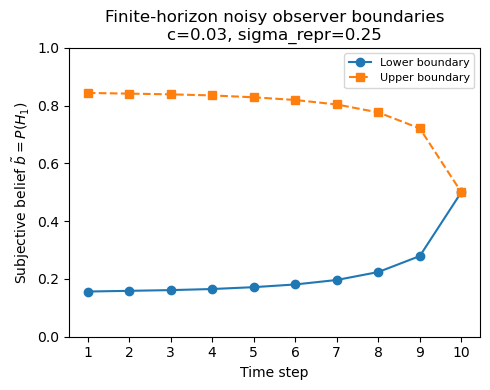

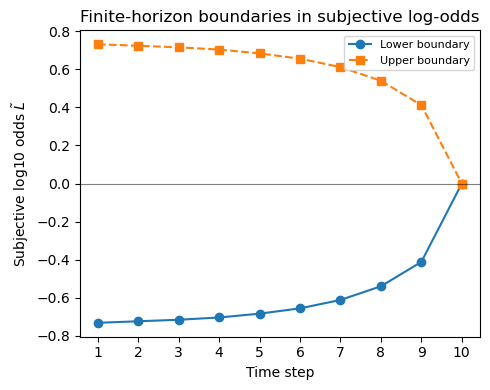

   trial  true_H  time_step  stim_idx  ground_L  subjective_L  ground_b  \
0      0       0          1        12       0.5      0.582609  0.759747   
1      0       0          2        12       1.0      1.308948  0.909091   
2      1       1          1         8       0.1     -0.034238  0.557312   
3      1       1          2         8       0.2      0.156905  0.613137   
4      1       1          3         2      -0.4     -0.435990  0.284747   

   subjective_b  action  
0      0.792738       2  
1      0.953201       1  
2      0.480301       2  
3      0.589352       2  
4      0.268175       2  
action
2    147633
0     25189
1     24811
Name: count, dtype: int64


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# Finite-horizon noisy-representation observer
# Terminal deadline: t = 11
# Decision times visualized: t = 1,...,10
# ============================================================

# -----------------------------
# Main parameters
# -----------------------------

c = 0.03
R_correct = 1.0
R_wrong = 0.0

n_trials = 5 * 10**4
max_timestep = 10
T_deadline = 11

# Same Gaussian representation noise as in the infinite-horizon example
sigma_repr = 0.25

rng = np.random.default_rng(1)

# ============================================================
# 1. Define 16 stimulus types and pA/pB
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio: log10 P(x|H1) / P(x|H0)
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Subjective log10-odds grid
# ============================================================

L_min = -4.0
L_max = 4.0
N_L = 2001

L_grid = np.linspace(L_min, L_max, N_L)

# Convert subjective log10 odds to subjective belief
b_grid = 1.0 / (1.0 + 10.0 ** (-L_grid))

# Stop value before deadline
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

# ============================================================
# 3. Gaussian quadrature for representation noise
# ============================================================

n_gh = 201
gh_x, gh_w = np.polynomial.hermite.hermgauss(n_gh)

noise_nodes = np.sqrt(2.0) * sigma_repr * gh_x
noise_weights = gh_w / np.sqrt(np.pi)

def interp_V(L_query, L_grid, V):
    """
    Interpolate value function over subjective log10 odds.
    """
    L_query = np.clip(L_query, L_grid[0], L_grid[-1])
    return np.interp(L_query, L_grid, V)

# ============================================================
# 4. Finite-horizon backward induction
#    V[11, :] = 0 everywhere
# ============================================================

V = np.zeros((T_deadline + 1, N_L))
Q_wait_all = np.zeros((T_deadline + 1, N_L))
policy_sample = np.zeros((T_deadline + 1, N_L), dtype=float)

lower_L = np.full(T_deadline + 1, np.nan)
upper_L = np.full(T_deadline + 1, np.nan)

lower_b = np.full(T_deadline + 1, np.nan)
upper_b = np.full(T_deadline + 1, np.nan)

# Terminal value at t = 11 is zero everywhere
V[T_deadline, :] = 0.0

# Backward induction: t = 10, 9, ..., 1
for t in range(T_deadline - 1, 0, -1):

    Q_wait = np.zeros_like(L_grid)

    for i, ell_i in enumerate(target_log_ratios):

        # Subjective predictive probability of observing stimulus i
        q_i = b_grid * pB[i] + (1 - b_grid) * pA[i]

        # Expected value over Gaussian representation noise
        expected_over_noise = np.zeros_like(L_grid)

        for node, weight in zip(noise_nodes, noise_weights):

            L_next = L_grid + ell_i + node

            expected_over_noise += weight * interp_V(
                L_next,
                L_grid,
                V[t + 1, :]
            )

        Q_wait += q_i * expected_over_noise

    Q_wait = -c + Q_wait
    Q_wait_all[t, :] = Q_wait

    # Bellman backup
    V[t, :] = np.maximum(G, Q_wait)

    continue_region = Q_wait > G
    policy_sample[t, :] = continue_region.astype(float)

    if np.any(continue_region):
        lower_L[t] = L_grid[continue_region][0]
        upper_L[t] = L_grid[continue_region][-1]
    else:
        lower_L[t] = 0.0
        upper_L[t] = 0.0

    lower_b[t] = 1.0 / (1.0 + 10.0 ** (-lower_L[t]))
    upper_b[t] = 1.0 / (1.0 + 10.0 ** (-upper_L[t]))

print(f"Finite-horizon noisy observer, c = {c}, sigma_repr = {sigma_repr}")
for t in range(1, max_timestep + 1):
    print(
        f"t={t:2d}: "
        f"L_lower={lower_L[t]: .3f}, L_upper={upper_L[t]: .3f}, "
        f"b_lower={lower_b[t]: .3f}, b_upper={upper_b[t]: .3f}"
    )

# ============================================================
# 5. Plot decision boundaries over time
# ============================================================

t_plot = np.arange(1, max_timestep + 1)

plt.figure(figsize=(5, 4))

plt.plot(
    t_plot,
    lower_b[1:max_timestep + 1],
    marker="o",
    label="Lower boundary"
)

plt.plot(
    t_plot,
    upper_b[1:max_timestep + 1],
    marker="s",
    linestyle="--",
    label="Upper boundary"
)

plt.xlabel("Time step")
plt.ylabel(r"Subjective belief $\tilde b=P(H_1)$")
plt.title(
    f"Finite-horizon noisy observer boundaries\n"
    f"c={c}, sigma_repr={sigma_repr}"
)
plt.ylim(0, 1)
plt.xticks(t_plot)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))

plt.plot(
    t_plot,
    lower_L[1:max_timestep + 1],
    marker="o",
    label="Lower boundary"
)

plt.plot(
    t_plot,
    upper_L[1:max_timestep + 1],
    marker="s",
    linestyle="--",
    label="Upper boundary"
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel("Time step")
plt.ylabel(r"Subjective log10 odds $\tilde L$")
plt.title("Finite-horizon boundaries in subjective log-odds")
plt.xticks(t_plot)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Simulate noisy observer
# ============================================================

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)  # 0 = H0/A, 1 = H1/B

    L_true = 0.0
    L_subj = 0.0

    for t in range(1, max_timestep + 1):

        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        ell = target_log_ratios[stim_idx]

        # Ground-truth perfect posterior log10 odds
        L_true += ell

        # Subjective noisy representation with perfect integration
        L_subj += ell + rng.normal(0.0, sigma_repr)

        b_true = 1.0 / (1.0 + 10.0 ** (-L_true))
        b_subj = 1.0 / (1.0 + 10.0 ** (-L_subj))

        # Apply time-dependent optimal policy in subjective space
        if L_subj <= lower_L[t]:
            action = 0   # choose A / H0
        elif L_subj >= upper_L[t]:
            action = 1   # choose B / H1
        else:
            action = 2   # continue sampling

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "ground_L": L_true,
            "subjective_L": L_subj,
            "ground_b": b_true,
            "subjective_b": b_subj,
            "action": action
        })

        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

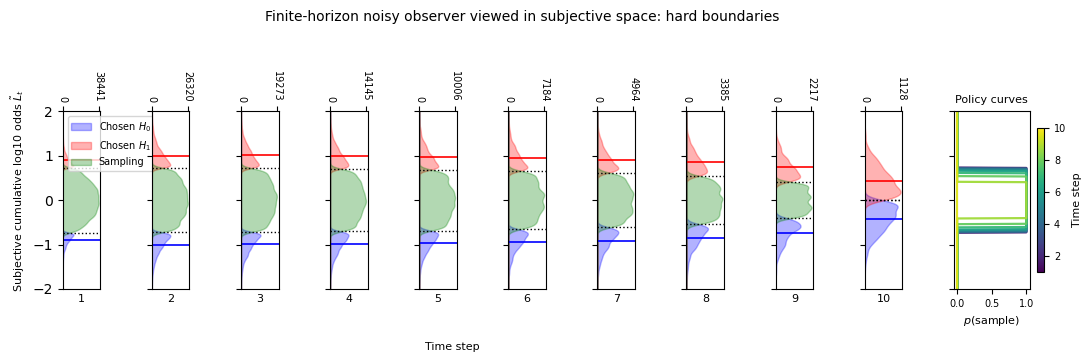

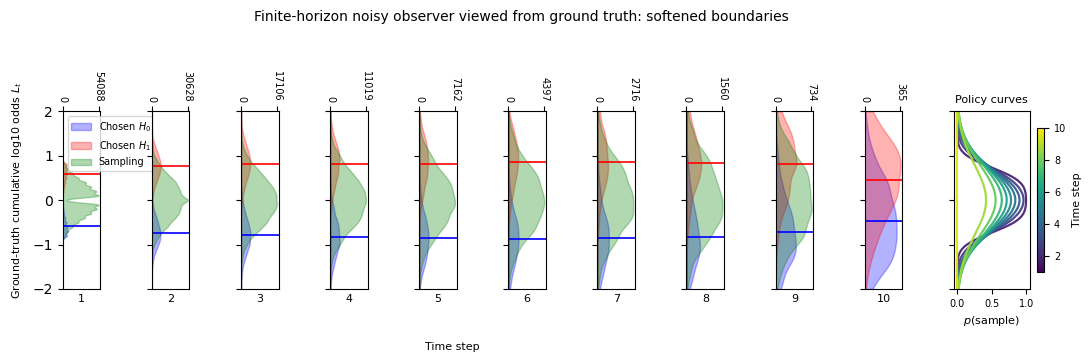

In [2]:
# ============================================================
# 7. Plotting helpers
# ============================================================

colors_action = {
    0: "blue",
    1: "red",
    2: "green"
}

labels_action = {
    0: r'Chosen $H_0$', 
    1: r'Chosen $H_1$', 
    2: r'Sampling'
}


time_colors = plt.cm.viridis(
    np.linspace(0.1, 0.95, max_timestep)
)

def empirical_policy_by_bins(
    df,
    y_col,
    y_min,
    y_max,
    n_bins=60,
    min_count=10
):
    """
    Empirical p(sample) as a function of y_col, separately by time.
    """
    bins = np.linspace(y_min, y_max, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    policy_by_t = {}

    for t in range(1, max_timestep + 1):

        dft = df[df["time_step"] == t]

        y = dft[y_col].to_numpy()
        is_sampling = (dft["action"] == 2).astype(float).to_numpy()

        p_emp = np.full_like(centers, np.nan, dtype=float)

        for k in range(n_bins):
            mask = (y >= bins[k]) & (y < bins[k + 1])

            if mask.sum() >= min_count:
                p_emp[k] = is_sampling[mask].mean()

        policy_by_t[t] = p_emp

    return centers, policy_by_t

def plot_finite_noisy_view(
    df,
    y_col,
    y_label,
    title,
    ground_truth_view=False
):
    """
    Left panels:
        distributions of chosen and sampling trials over time.

    Right panel:
        p(sample) as a function of subjective or ground-truth log10 odds.

    If ground_truth_view=True:
        draw soft decision boundaries as grayscale shadows.
    """

    y_min = -2.0
    y_max = 2.0
    y_grid = np.linspace(y_min, y_max, 500)

    fig, axes = plt.subplots(
        1,
        max_timestep + 1,
        figsize=(11.5, 3.4),
        sharey=True,
        gridspec_kw={
            "width_ratios": [1] * max_timestep + [2.4]
        }
    )

    dist_axes = axes[:-1]
    policy_ax = axes[-1]

    # ========================================================
    # Left: distribution panels
    # ========================================================

    for t in range(1, max_timestep + 1):

        ax = dist_axes[t - 1]
        dft = df[df["time_step"] == t]

        max_density = 0.0

        # Ground-truth view:
        # soft boundary shadow induced by subjective Gaussian noise.
        if ground_truth_view:

            s_t = sigma_repr * np.sqrt(t)

            p_sample_soft = (
                norm.cdf((upper_L[t] - y_grid) / s_t)
                -
                norm.cdf((lower_L[t] - y_grid) / s_t)
            )

            # Draw grayscale shadow beneath distributions.
            # Darker gray = higher probability of sampling.
            """
            for k in range(len(y_grid) - 1):
                alpha_k = 1 - p_sample_soft[k]

                if alpha_k > 0.005:
                    ax.axhspan(
                        y_grid[k],
                        y_grid[k + 1],
                        color="black",
                        alpha=alpha_k,
                        linewidth=0
                    )
            """

        for action in [0, 1, 2]:

            action_data = dft[dft["action"] == action]

            if action_data.empty:
                continue

            y = action_data[y_col].to_numpy()

            if len(y) < 3 or np.std(y) == 0:
                continue

            kde = gaussian_kde(y)
            density = kde(y_grid)

            density_scaled = density * len(y)
            max_density = max(max_density, density_scaled.max())

            ax.fill_betweenx(
                y_grid,
                0,
                density_scaled,
                color=colors_action[action],
                alpha=0.3,
                label=labels_action[action] if t == 1 else None
            )

            if action in [0, 1]:
                mean_y = np.mean(y)

                ax.axhline(
                    mean_y,
                    color=colors_action[action],
                    linewidth=1.2
                )

        # Subjective view:
        # hard optimal boundaries.
        if not ground_truth_view:
            ax.axhline(
                lower_L[t],
                color="black",
                linestyle=":",
                linewidth=1
            )
            ax.axhline(
                upper_L[t],
                color="black",
                linestyle=":",
                linewidth=1
            )

        # Ground-truth view:
        """
        # faint reference lines for the subjective boundary centers.
        if ground_truth_view:
            
            ax.axhline(
                lower_L[t],
                color="gray",
                linestyle=":",
                linewidth=0.8,
                alpha=0.6
            )
            ax.axhline(
                upper_L[t],
                color="gray",
                linestyle=":",
                linewidth=0.8,
                alpha=0.6
            )
        """
        ax.set_ylim(y_min, y_max)

        if max_density > 0:
            ax.set_xlim(0, max_density * 1.05)
            ax.set_xticks([0, int(max_density)])
        else:
            ax.set_xlim(0, 1)
            ax.set_xticks([0, 1])

        ax.xaxis.set_ticks_position("top")
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            labelbottom=False
        )

        ax.set_xticklabels(
            [str(int(x)) for x in ax.get_xticks()],
            rotation=270,
            fontsize=7
        )

        ax.set_xlabel(str(t), fontsize=8)

    # ========================================================
    # Right: policy curves
    # ========================================================

    centers, empirical_policy = empirical_policy_by_bins(
        df,
        y_col=y_col,
        y_min=y_min,
        y_max=y_max,
        n_bins=60,
        min_count=10
    )

    for idx, t in enumerate(range(1, max_timestep + 1)):

        color_t = time_colors[idx]

        if ground_truth_view:

            # From the experimenter's ground-truth axis:
            # p(sample | L_true) is softened by accumulated noise.
            s_t = sigma_repr * np.sqrt(t)

            p_sample_optimal = (
                norm.cdf((upper_L[t] - y_grid) / s_t)
                -
                norm.cdf((lower_L[t] - y_grid) / s_t)
            )

        else:

            # From subjective axis:
            # optimal policy is still a hard boundary.
            p_sample_optimal = (
                (y_grid > lower_L[t])
                &
                (y_grid < upper_L[t])
            ).astype(float)

        # Optimal policy curve
        policy_ax.plot(
            p_sample_optimal,
            y_grid,
            color=color_t,
            linewidth=1.6,
            alpha=0.95
        )
        
        """
        # Empirical simulation curve
        policy_ax.plot(
            empirical_policy[t],
            centers,
            color=color_t,
            linestyle="--",
            linewidth=1.1,
            alpha=0.85
        )
        """

    policy_ax.set_xlim(-0.05, 1.05)
    policy_ax.set_xticks([0, 0.5, 1.0])
    policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
    policy_ax.set_title("Policy curves", fontsize=8)
    policy_ax.tick_params(axis="x", labelsize=7)


    # Colorbar for time
    sm = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=plt.Normalize(vmin=1, vmax=max_timestep)
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=policy_ax,
        fraction=0.08,
        pad=0.08
    )
    cbar.set_label("Time step", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.text(
        0.44,
        0.03,
        "Time step",
        ha="center",
        fontsize=8
    )

    fig.text(
        0.055,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=8
    )

    fig.suptitle(title, fontsize=10, y=1.03)

    for ax in dist_axes:
        ax.label_outer()

    dist_axes[0].legend(loc="best", fontsize=7)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
    plt.show()

# ============================================================
# 8A. Subjective view
# ============================================================

plot_finite_noisy_view(
    df=df_sim,
    y_col="subjective_L",
    y_label=r"Subjective cumulative log10 odds $\tilde L_t$",
    title=(
        "Finite-horizon noisy observer viewed in subjective space: "
        "hard boundaries"
    ),
    ground_truth_view=False
)

# ============================================================
# 8B. Ground-truth view
# ============================================================

plot_finite_noisy_view(
    df=df_sim,
    y_col="ground_L",
    y_label=r"Ground-truth cumulative log10 odds $L_t$",
    title=(
        "Finite-horizon noisy observer viewed from ground truth: "
        "softened boundaries"
    ),
    ground_truth_view=True
)